# Individual LSTM Experiment Multivariat Dengan Lookback 30

Eksperimen ini mengimplementasikan pemodelan **Multivariate LSTM** untuk peramalan penjualan harian (*store sales forecasting*) pada 6 kombinasi toko dan kategori produk (*family*).

### Konfigurasi Fitur Multivariat (Set A - 10 Fitur):
1. `sales`: Target penjualan historis (index 0).
2. `onpromotion`: Jumlah item yang sedang dipromosikan.
3. `promo_rolling_mean_7`: Rata-rata promosi bergerak 7 hari.
4. `oil_price`: Harga minyak mentah WTI harian (diinterpolasi).
5. `is_holiday`: Indikator hari libur (nasional, regional per provinsi toko, lokal per kota toko).
6. `is_weekend`: Indikator akhir pekan (Sabtu & Minggu).
7. `is_payday`: Indikator hari gajian (*quincena*: tgl 15 dan akhir bulan).
8. `day_sin` & `day_cos`: *Cyclical encoding* hari dalam seminggu.
9. `sales_lag_7`: Penjualan 7 hari sebelumnya (musiman mingguan langsung).

### Metodologi & Pencegahan Data Leakage:
- **Dual Scaler Strategy**: Skaler matriks fitur `scaler_features` dan skaler target `scaler_target` dipisahkan untuk menjamin proses `inverse_transform` yang presisi.
- **No Data Leakage**: Skaler hanya di-`fit` pada data latih (80% awal), lalu data uji (20% akhir) di-`transform` dengan skaler tersebut.
- **Lookback**: 30 hari (*window sequences*).
- **Arsitektur Model**: Simple LSTM (1 Layer 64 unit) & Complex LSTM (2 Layer 64 & 32 unit + Dropout).

### 1. Import Library dan Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_log_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import warnings
warnings.filterwarnings('ignore')

# Set seed untuk reproduktibilitas
np.random.seed(42)
tf.random.set_seed(42)

### 2. Load Dataset
Memuat dataset utama `train.csv` beserta data eksternal pendukung (`stores.csv`, `oil.csv`, dan `holidays_events.csv`).

In [2]:
# Load dataset
df_train = pd.read_csv('../datasets/train.csv', usecols=['date', 'store_nbr', 'family', 'sales', 'onpromotion'], parse_dates=['date'])
df_stores = pd.read_csv('../datasets/stores.csv')
df_oil = pd.read_csv('../datasets/oil.csv', parse_dates=['date'])
df_holidays = pd.read_csv('../datasets/holidays_events.csv', parse_dates=['date'])

print(f"Train shape: {df_train.shape}")
print(f"Stores shape: {df_stores.shape}")
print(f"Oil shape: {df_oil.shape}")
print(f"Holidays shape: {df_holidays.shape}")
df_train.head()

Train shape: (3000888, 5)
Stores shape: (54, 5)
Oil shape: (1218, 2)
Holidays shape: (350, 6)


### 3. Fungsi Pembantu (Data Preparation Multivariat, Model Building, & Evaluasi)
Fungsi-fungsi pembantu ini digunakan untuk:
1. Memproses dan mengekstraksi 10 fitur multivariat (Set A).
2. Membentuk sekuensial data 3 dimensi `(N, look_back, num_features)`.
3. Membangun model LSTM Sederhana (*Simple*) & Kompleks (*Complex 2-Layer*).
4. Melatih model dan mengevaluasi hasil prediksi pada skala asli penjualan menggunakan metrik **RMSLE** (*Root Mean Squared Logarithmic Error*).

In [3]:
# 1. Preprocessing Data Harga Minyak (Oil)
oil_complete = pd.DataFrame({'date': pd.date_range(df_train['date'].min(), df_train['date'].max())})
oil_complete = oil_complete.merge(df_oil, on='date', how='left')
oil_complete['oil_price'] = oil_complete['dcoilwtico'].interpolate(method='linear').bfill().ffill()
oil_complete = oil_complete[['date', 'oil_price']]

# 2. Filter Hari Libur yang Tidak Ditransfer
valid_holidays = df_holidays[df_holidays['transferred'] == False].copy()

def prepare_data_multivariate_lstm(df_train, df_stores, oil_df, holidays_df, store_nbr, family, look_back=30, train_ratio=0.8):
    # Ambil info kota dan provinsi toko
    store_info = df_stores[df_stores['store_nbr'] == store_nbr].iloc[0]
    store_city = store_info['city']
    store_state = store_info['state']

    # Filter data deret waktu toko dan kategori produk
    df_filtered = df_train[(df_train['store_nbr'] == store_nbr) & (df_train['family'] == family)].copy()
    df_filtered = df_filtered.groupby('date')[['sales', 'onpromotion']].sum().reset_index().set_index('date').asfreq('D').fillna(0).reset_index()

    # Gabungkan dengan harga minyak
    df_filtered = df_filtered.merge(oil_df, on='date', how='left')

    # Ekstraksi Hari Libur Berdasarkan Wilayah (National, Regional, Local)
    nat_h = holidays_df[holidays_df['locale'] == 'National']['date'].unique()
    reg_h = holidays_df[(holidays_df['locale'] == 'Regional') & (holidays_df['locale_name'] == store_state)]['date'].unique()
    loc_h = holidays_df[(holidays_df['locale'] == 'Local') & (holidays_df['locale_name'] == store_city)]['date'].unique()
    all_h = set(nat_h).union(set(reg_h)).union(set(loc_h))
    df_filtered['is_holiday'] = df_filtered['date'].isin(all_h).astype(int)

    # Fitur Kalender dan Siklus
    df_filtered['dayofweek'] = df_filtered['date'].dt.dayofweek
    df_filtered['is_weekend'] = (df_filtered['dayofweek'] >= 5).astype(int)
    df_filtered['is_payday'] = ((df_filtered['date'].dt.day == 15) | df_filtered['date'].dt.is_month_end).astype(int)
    df_filtered['day_sin'] = np.sin(2 * np.pi * df_filtered['dayofweek'] / 7)
    df_filtered['day_cos'] = np.cos(2 * np.pi * df_filtered['dayofweek'] / 7)

    # Fitur Promosi & Lag Penjualan
    df_filtered['promo_rolling_mean_7'] = df_filtered['onpromotion'].rolling(7, min_periods=1).mean()
    df_filtered['sales_lag_7'] = df_filtered['sales'].shift(7).bfill()

    # Fitur Set A (10 Fitur Multivariat) - Target 'sales' wajib berada di indeks 0
    feature_cols = ['sales', 'onpromotion', 'promo_rolling_mean_7', 'oil_price', 'is_holiday', 'is_weekend', 'is_payday', 'day_sin', 'day_cos', 'sales_lag_7']
    
    values = df_filtered[feature_cols].values
    sales_raw = df_filtered['sales'].values.reshape(-1, 1)

    # Pembuatan Sekuens Windowing
    X_list, y_list = [], []
    for i in range(len(values) - look_back):
        X_list.append(values[i : i + look_back, :])
        y_list.append(values[i + look_back, 0])
    
    X_arr = np.array(X_list)
    y_arr = np.array(y_list).reshape(-1, 1)

    train_size = int(len(X_arr) * train_ratio)

    # Normalisasi Fitur (Fit hanya pada Train untuk mencegah Data Leakage)
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    X_train_raw = X_arr[:train_size]
    X_test_raw = X_arr[train_size:]

    N_train, T, F = X_train_raw.shape
    N_test = X_test_raw.shape[0]

    scaler_features.fit(X_train_raw.reshape(-1, F))
    X_train = scaler_features.transform(X_train_raw.reshape(-1, F)).reshape(N_train, T, F)
    X_test = scaler_features.transform(X_test_raw.reshape(-1, F)).reshape(N_test, T, F)

    # Normalisasi Target Khusus untuk Inverse Transform Akurat
    scaler_target = MinMaxScaler(feature_range=(0, 1))
    y_train_raw = y_arr[:train_size]
    y_test_raw = y_arr[train_size:]

    y_train = scaler_target.fit_transform(y_train_raw).flatten()
    y_test = scaler_target.transform(y_test_raw).flatten()

    actual_sales = sales_raw[look_back:]
    actual_y_test = actual_sales[train_size:]

    return {
        'df_filtered': df_filtered,
        'feature_cols': feature_cols,
        'scaler_features': scaler_features,
        'scaler_target': scaler_target,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'actual_y_test': actual_y_test,
        'look_back': look_back,
        'num_features': F
    }

def build_simple_lstm(look_back=30, num_features=10):
    tf.random.set_seed(42)
    model = Sequential()
    model.add(Input(shape=(look_back, num_features)))
    model.add(LSTM(64, activation='tanh', dropout=0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_complex_lstm(look_back=30, num_features=10):
    tf.random.set_seed(42)
    model = Sequential()
    model.add(Input(shape=(look_back, num_features)))
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32, activation='tanh'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def train_and_evaluate(model, data_dict, model_name, store_nbr, family, epochs=50, batch_size=32):
    X_train = data_dict['X_train']
    y_train = data_dict['y_train']
    X_test = data_dict['X_test']
    y_test = data_dict['y_test']
    scaler_target = data_dict['scaler_target']
    actual_y_test = data_dict['actual_y_test']
    df_filtered = data_dict['df_filtered']

    print(f"=== Training {model_name} (Store {store_nbr} - {family}) ===")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    # Plot Learning Curve
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.title(f'Learning Curve {model_name} (Multivariat) - Store {store_nbr} | {family}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Prediksi & Inverse Transform
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_target.inverse_transform(y_pred_scaled)
    y_pred = np.where(y_pred < 0, 0, y_pred)

    # RMSLE Evaluation
    rmsle = root_mean_squared_log_error(actual_y_test, y_pred)
    print(f"[{model_name}] RMSLE (Store {store_nbr} - {family}): {rmsle:.4f}\n")

    # Plot Actual vs Predicted
    plt.figure(figsize=(14, 5))
    plt.plot(df_filtered['date'].iloc[-len(actual_y_test):], actual_y_test, label='Actual Sales', color='blue')
    plt.plot(df_filtered['date'].iloc[-len(y_pred):], y_pred, label=f'Predicted Sales ({model_name} Multivariat)', color='red', alpha=0.8)
    plt.title(f'Actual vs Predicted Sales ({model_name} Multivariat) - Store {store_nbr} | {family}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

    return rmsle

---
## Kombinasi 1: Store 23 - EGGS

In [4]:
# Prepare Data Kombinasi 1 (Store 23, EGGS)
data_comb1 = prepare_data_multivariate_lstm(df_train, df_stores, oil_complete, valid_holidays, store_nbr=23, family='EGGS', look_back=30)
print(f"Data Kombinasi 1 (Store 23 - EGGS) Siap (Multivariat)!")
print(f"Shape X_train: {data_comb1['X_train'].shape}, Shape X_test: {data_comb1['X_test'].shape}")
print(f"Jumlah Fitur: {data_comb1['num_features']} -> {data_comb1['feature_cols']}")

Data Kombinasi 1 (Store 23 - EGGS) Siap (Multivariat)!
Shape X_train: (1326, 30, 10), Shape X_test: (332, 30, 10)
Jumlah Fitur: 10 -> ['sales', 'onpromotion', 'promo_rolling_mean_7', 'oil_price', 'is_holiday', 'is_weekend', 'is_payday', 'day_sin', 'day_cos', 'sales_lag_7']


### Kombinasi 1 - Model LSTM Sederhana

=== Training Simple LSTM (Store 23 - EGGS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0304 - val_loss: 0.0104
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0137 - val_loss: 0.0086
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0106 - val_loss: 0.0085
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0106 - val_loss: 0.0085
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0101 - val_loss: 0.0093
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0096 - val_loss: 0.0093
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0095 - val_loss: 0.0087
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0098 - val_loss: 0.0094
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0094 - val_loss: 0.0089
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0097 - val_loss: 0.0090
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0093 - val_loss: 0.0089
Epoch 12/50
42/4

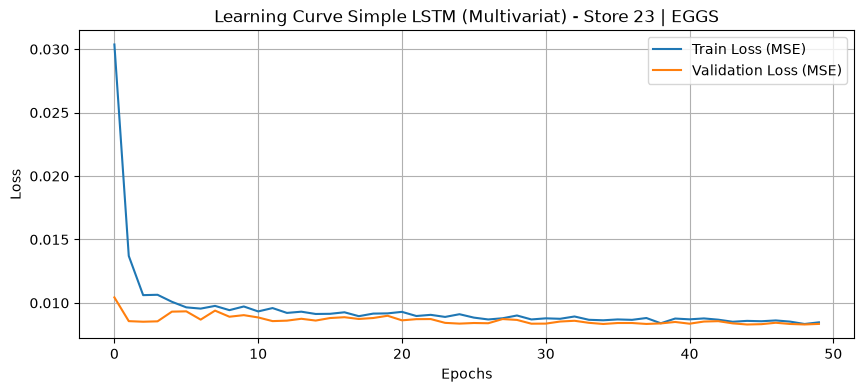

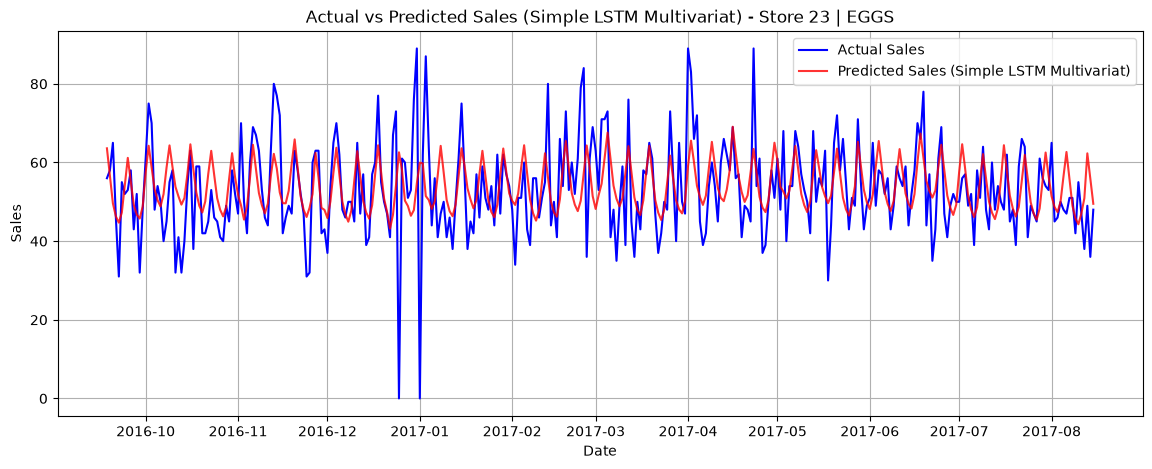

In [5]:
model_simple_comb1 = build_simple_lstm(look_back=30, num_features=data_comb1['num_features'])
rmsle_simple_comb1 = train_and_evaluate(
    model_simple_comb1, data_comb1, 
    model_name="Simple LSTM", store_nbr=23, family="EGGS", 
    epochs=50, batch_size=32
)

### Kombinasi 1 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 23 - EGGS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0322 - val_loss: 0.0102
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0157 - val_loss: 0.0095
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0134 - val_loss: 0.0093
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0139 - val_loss: 0.0092
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0124 - val_loss: 0.0089
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0122 - val_loss: 0.0084
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0118 - val_loss: 0.0084
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0115 - val_loss: 0.0084
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0116 - val_loss: 0.0084
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0111 - val_loss: 0.0085
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0110 - val_loss: 0.0091
Epoch 12/50
42/

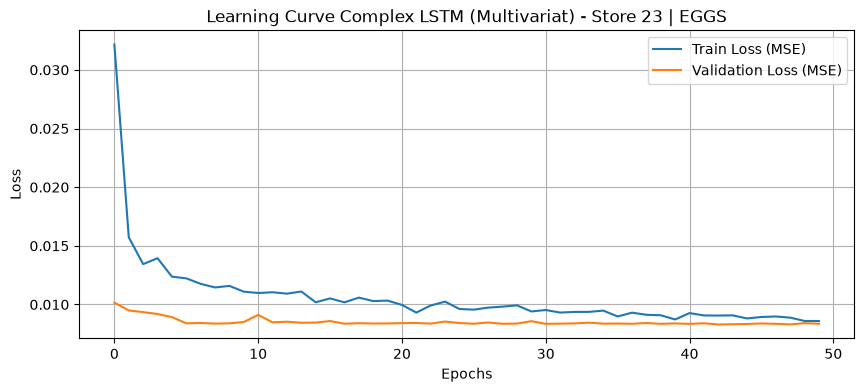

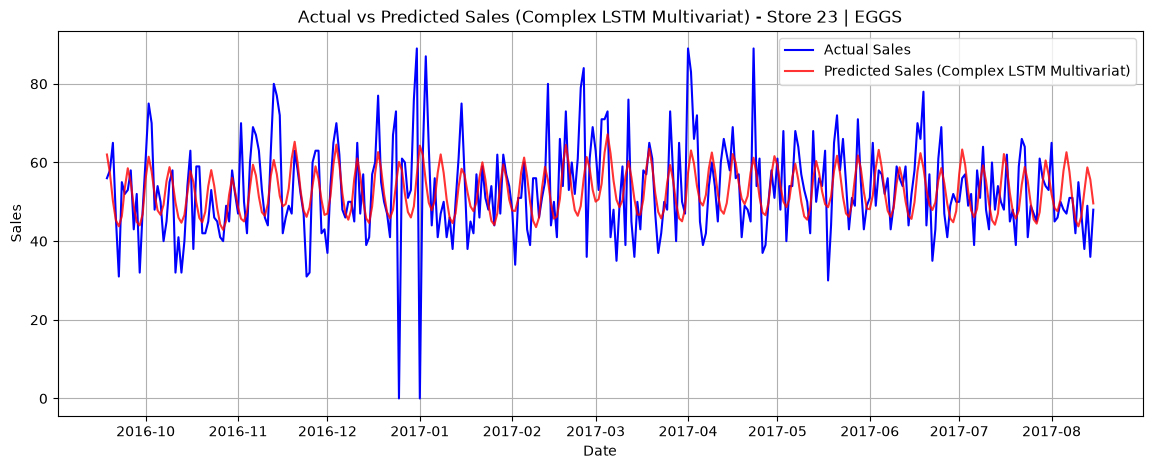

In [6]:
model_complex_comb1 = build_complex_lstm(look_back=30, num_features=data_comb1['num_features'])
rmsle_complex_comb1 = train_and_evaluate(
    model_complex_comb1, data_comb1, 
    model_name="Complex LSTM", store_nbr=23, family="EGGS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 2: Store 54 - MEATS

In [7]:
# Prepare Data Kombinasi 2 (Store 54, MEATS)
data_comb2 = prepare_data_multivariate_lstm(df_train, df_stores, oil_complete, valid_holidays, store_nbr=54, family='MEATS', look_back=30)
print(f"Data Kombinasi 2 (Store 54 - MEATS) Siap (Multivariat)!")
print(f"Shape X_train: {data_comb2['X_train'].shape}, Shape X_test: {data_comb2['X_test'].shape}")
print(f"Jumlah Fitur: {data_comb2['num_features']} -> {data_comb2['feature_cols']}")

Data Kombinasi 2 (Store 54 - MEATS) Siap (Multivariat)!
Shape X_train: (1326, 30, 10), Shape X_test: (332, 30, 10)
Jumlah Fitur: 10 -> ['sales', 'onpromotion', 'promo_rolling_mean_7', 'oil_price', 'is_holiday', 'is_weekend', 'is_payday', 'day_sin', 'day_cos', 'sales_lag_7']


### Kombinasi 2 - Model LSTM Sederhana

=== Training Simple LSTM (Store 54 - MEATS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0507 - val_loss: 0.0130
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0190 - val_loss: 0.0125
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0165 - val_loss: 0.0119
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0150 - val_loss: 0.0120
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0152 - val_loss: 0.0118
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0149 - val_loss: 0.0120
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0145 - val_loss: 0.0122
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0143 - val_loss: 0.0121
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0145 - val_loss: 0.0118
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0141 - val_loss: 0.0119
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0142 - val_loss: 0.0118
Epoch 12/50
42/

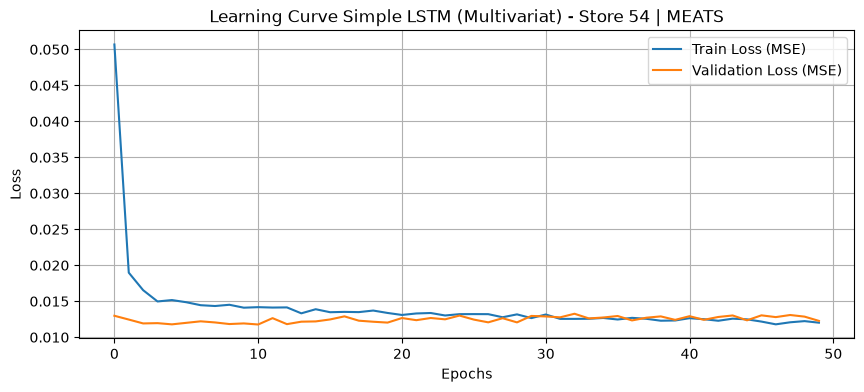

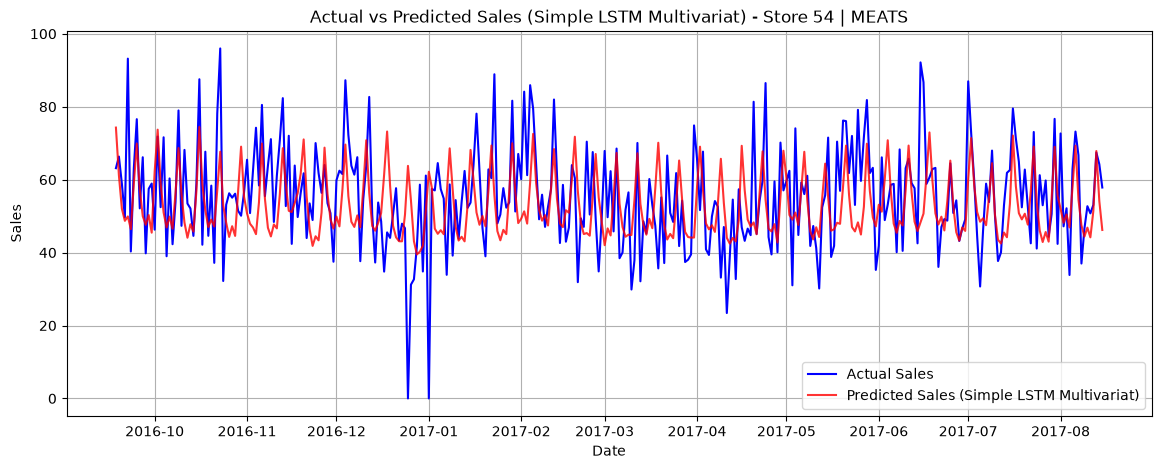

In [8]:
model_simple_comb2 = build_simple_lstm(look_back=30, num_features=data_comb2['num_features'])
rmsle_simple_comb2 = train_and_evaluate(
    model_simple_comb2, data_comb2, 
    model_name="Simple LSTM", store_nbr=54, family="MEATS", 
    epochs=50, batch_size=32
)

### Kombinasi 2 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 54 - MEATS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0288 - val_loss: 0.0121
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0207 - val_loss: 0.0117
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0190 - val_loss: 0.0114
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0180 - val_loss: 0.0112
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0173 - val_loss: 0.0113
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0172 - val_loss: 0.0114
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0160 - val_loss: 0.0116
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0156 - val_loss: 0.0118
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0154 - val_loss: 0.0119
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0148 - val_loss: 0.0121
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0152 - val_loss: 0.0120
Epoch 12/50
42

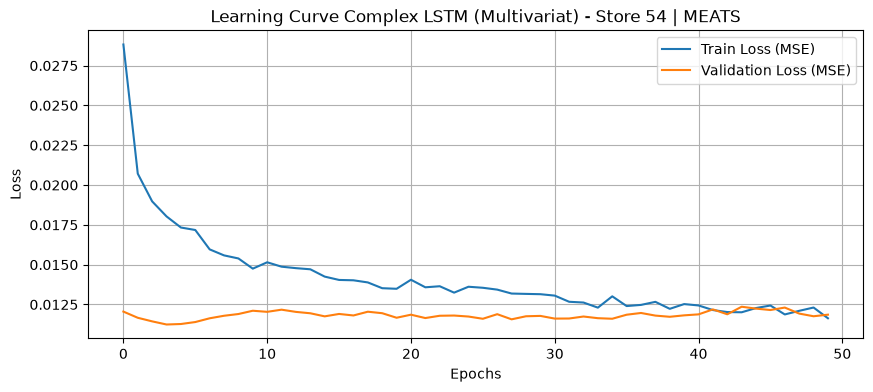

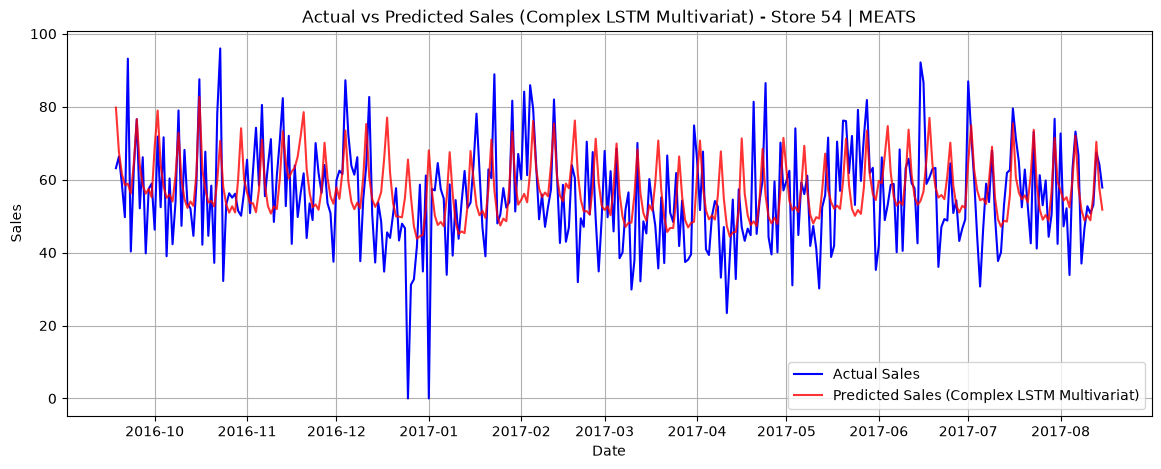

In [9]:
model_complex_comb2 = build_complex_lstm(look_back=30, num_features=data_comb2['num_features'])
rmsle_complex_comb2 = train_and_evaluate(
    model_complex_comb2, data_comb2, 
    model_name="Complex LSTM", store_nbr=54, family="MEATS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 3: Store 19 - PREPARED FOODS

In [10]:
# Prepare Data Kombinasi 3 (Store 19, PREPARED FOODS)
data_comb3 = prepare_data_multivariate_lstm(df_train, df_stores, oil_complete, valid_holidays, store_nbr=19, family='PREPARED FOODS', look_back=30)
print(f"Data Kombinasi 3 (Store 19 - PREPARED FOODS) Siap (Multivariat)!")
print(f"Shape X_train: {data_comb3['X_train'].shape}, Shape X_test: {data_comb3['X_test'].shape}")
print(f"Jumlah Fitur: {data_comb3['num_features']} -> {data_comb3['feature_cols']}")

Data Kombinasi 3 (Store 19 - PREPARED FOODS) Siap (Multivariat)!
Shape X_train: (1326, 30, 10), Shape X_test: (332, 30, 10)
Jumlah Fitur: 10 -> ['sales', 'onpromotion', 'promo_rolling_mean_7', 'oil_price', 'is_holiday', 'is_weekend', 'is_payday', 'day_sin', 'day_cos', 'sales_lag_7']


### Kombinasi 3 - Model LSTM Sederhana

=== Training Simple LSTM (Store 19 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0315 - val_loss: 0.0235
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0207 - val_loss: 0.0232
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0187 - val_loss: 0.0242
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0191 - val_loss: 0.0250
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0184 - val_loss: 0.0266
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0186 - val_loss: 0.0252
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0188 - val_loss: 0.0243
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0177 - val_loss: 0.0261
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0181 - val_loss: 0.0258
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0175 - val_loss: 0.0258
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0177 - val_loss: 0.0251
Epoch 

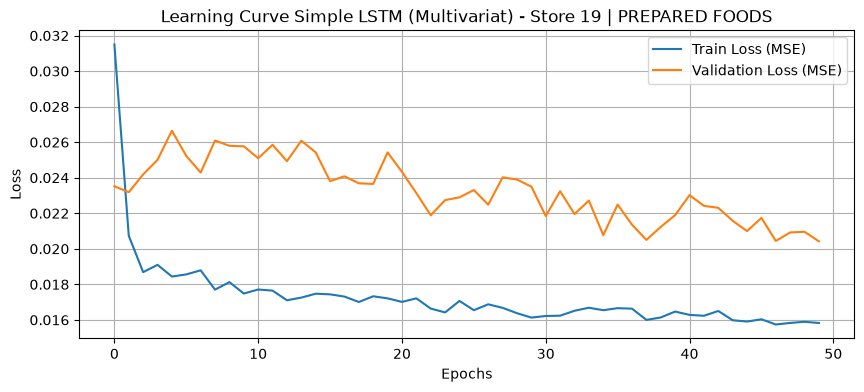

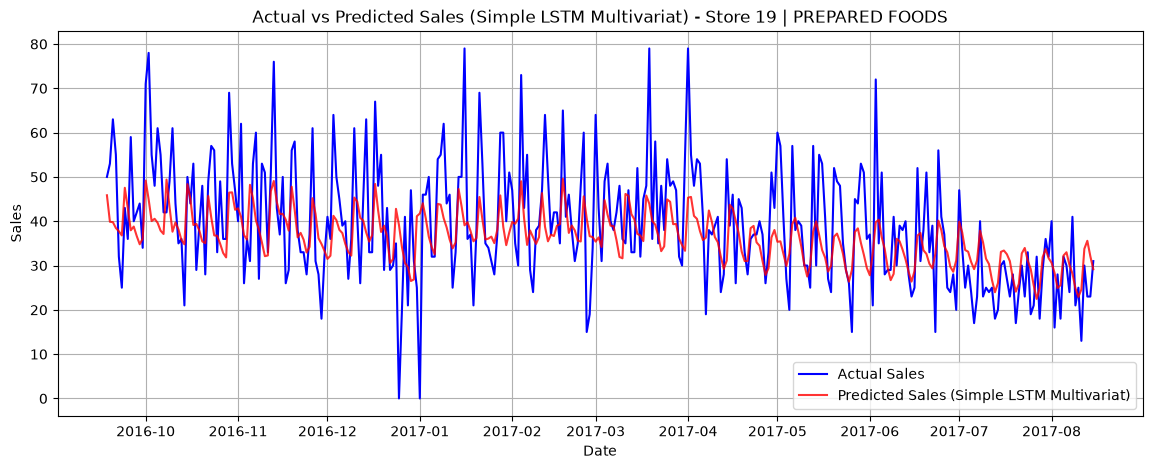

In [11]:
model_simple_comb3 = build_simple_lstm(look_back=30, num_features=data_comb3['num_features'])
rmsle_simple_comb3 = train_and_evaluate(
    model_simple_comb3, data_comb3, 
    model_name="Simple LSTM", store_nbr=19, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

### Kombinasi 3 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 19 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0370 - val_loss: 0.0253
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0219 - val_loss: 0.0246
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0215 - val_loss: 0.0246
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0205 - val_loss: 0.0243
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0194 - val_loss: 0.0237
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0191 - val_loss: 0.0237
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0192 - val_loss: 0.0234
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0190 - val_loss: 0.0212
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0187 - val_loss: 0.0231
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0186 - val_loss: 0.0219
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0183 - val_loss: 0.0214
Epoch

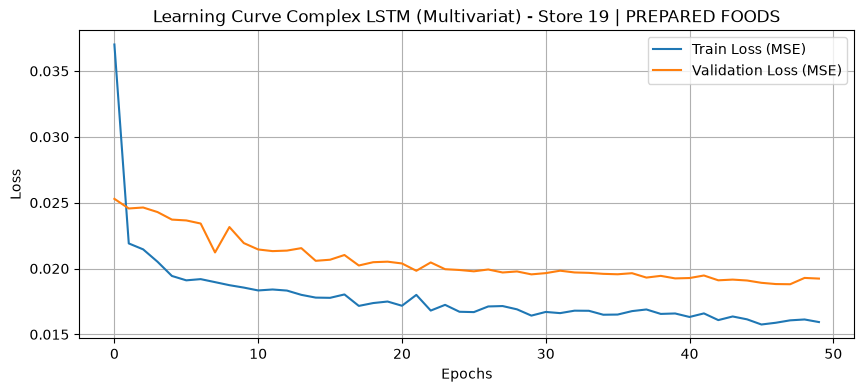

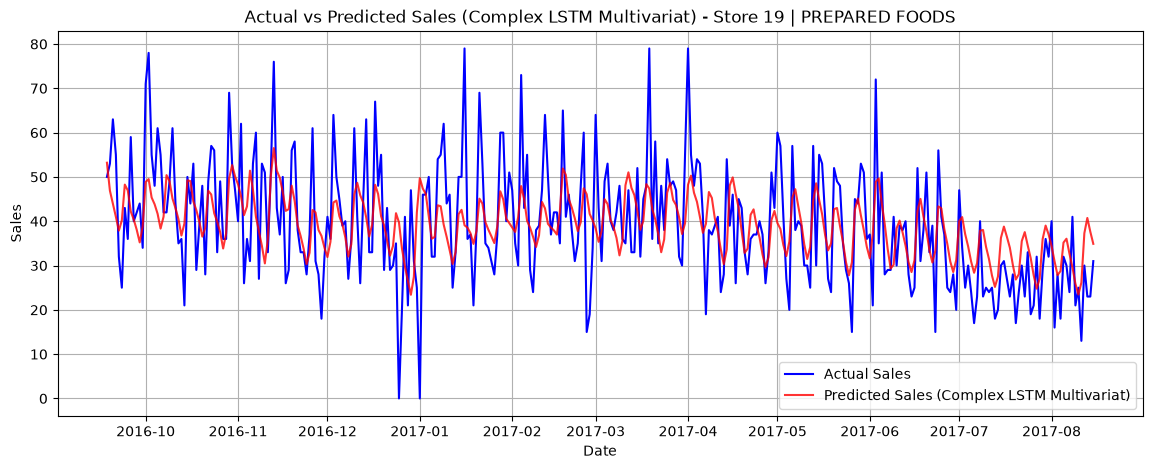

In [12]:
model_complex_comb3 = build_complex_lstm(look_back=30, num_features=data_comb3['num_features'])
rmsle_complex_comb3 = train_and_evaluate(
    model_complex_comb3, data_comb3, 
    model_name="Complex LSTM", store_nbr=19, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 4: Store 7 - SEAFOOD

In [13]:
# Prepare Data Kombinasi 4 (Store 7, SEAFOOD)
data_comb4 = prepare_data_multivariate_lstm(df_train, df_stores, oil_complete, valid_holidays, store_nbr=7, family='SEAFOOD', look_back=30)
print(f"Data Kombinasi 4 (Store 7 - SEAFOOD) Siap (Multivariat)!")
print(f"Shape X_train: {data_comb4['X_train'].shape}, Shape X_test: {data_comb4['X_test'].shape}")
print(f"Jumlah Fitur: {data_comb4['num_features']} -> {data_comb4['feature_cols']}")

Data Kombinasi 4 (Store 7 - SEAFOOD) Siap (Multivariat)!
Shape X_train: (1326, 30, 10), Shape X_test: (332, 30, 10)
Jumlah Fitur: 10 -> ['sales', 'onpromotion', 'promo_rolling_mean_7', 'oil_price', 'is_holiday', 'is_weekend', 'is_payday', 'day_sin', 'day_cos', 'sales_lag_7']


### Kombinasi 4 - Model LSTM Sederhana

=== Training Simple LSTM (Store 7 - SEAFOOD) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0472 - val_loss: 0.0232
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0213 - val_loss: 0.0327
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0204 - val_loss: 0.0317
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0197 - val_loss: 0.0280
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0190 - val_loss: 0.0265
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0187 - val_loss: 0.0237
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0187 - val_loss: 0.0279
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0187 - val_loss: 0.0259
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0184 - val_loss: 0.0253
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0184 - val_loss: 0.0248
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0184 - val_loss: 0.0275
Epoch 12/50
42

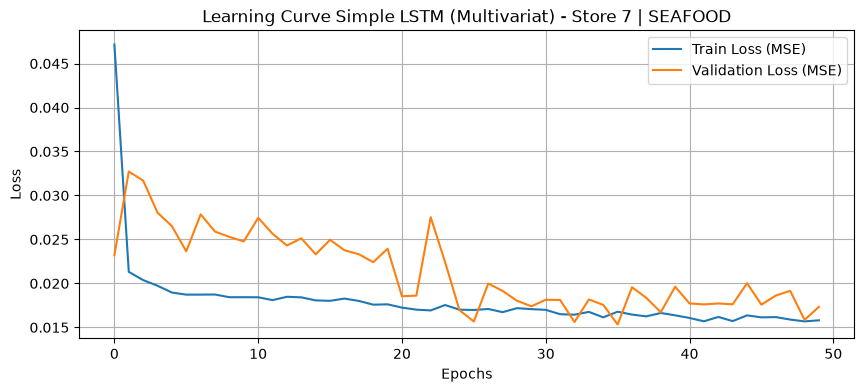

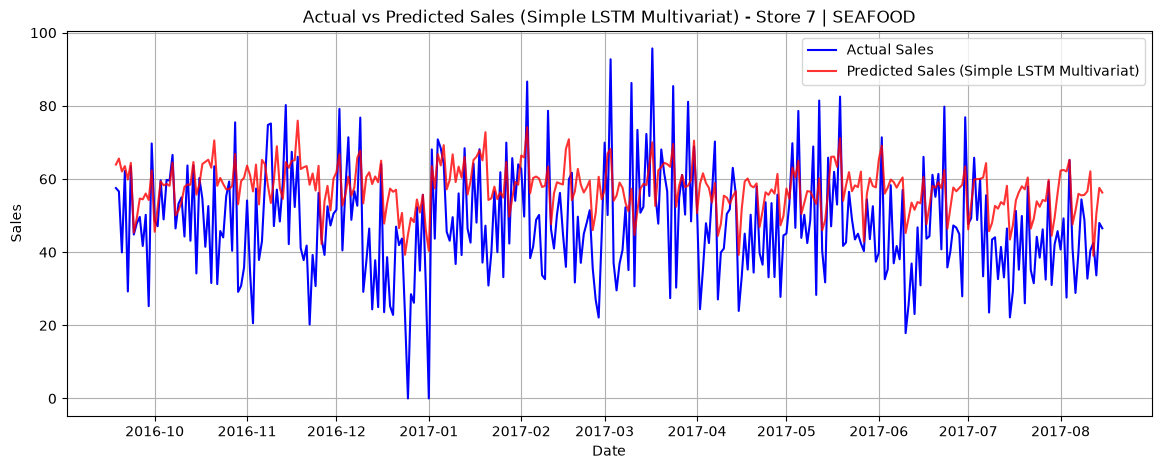

In [14]:
model_simple_comb4 = build_simple_lstm(look_back=30, num_features=data_comb4['num_features'])
rmsle_simple_comb4 = train_and_evaluate(
    model_simple_comb4, data_comb4, 
    model_name="Simple LSTM", store_nbr=7, family="SEAFOOD", 
    epochs=50, batch_size=32
)

### Kombinasi 4 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 7 - SEAFOOD) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0559 - val_loss: 0.0231
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0231 - val_loss: 0.0217
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0228 - val_loss: 0.0222
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0221 - val_loss: 0.0217
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0203 - val_loss: 0.0189
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0200 - val_loss: 0.0192
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0211 - val_loss: 0.0199
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0197 - val_loss: 0.0193
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0200 - val_loss: 0.0185
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0201 - val_loss: 0.0186
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0204 - val_loss: 0.0189
Epoch 12/50
4

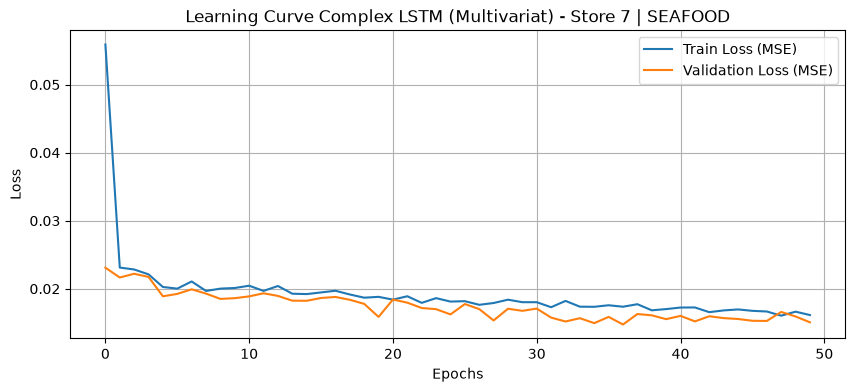

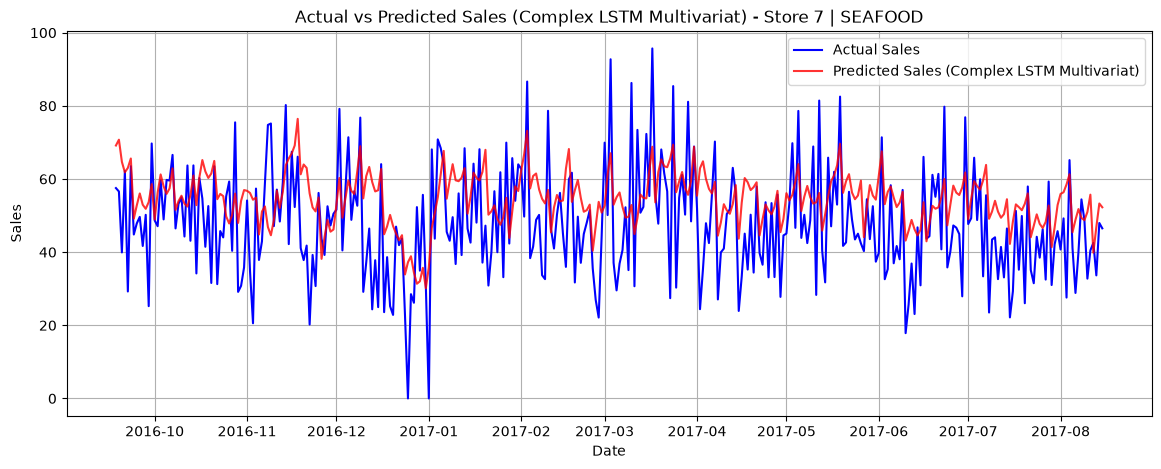

In [15]:
model_complex_comb4 = build_complex_lstm(look_back=30, num_features=data_comb4['num_features'])
rmsle_complex_comb4 = train_and_evaluate(
    model_complex_comb4, data_comb4, 
    model_name="Complex LSTM", store_nbr=7, family="SEAFOOD", 
    epochs=50, batch_size=32
)

---
## Kombinasi 5: Store 23 - PREPARED FOODS

In [16]:
# Prepare Data Kombinasi 5 (Store 23, PREPARED FOODS)
data_comb5 = prepare_data_multivariate_lstm(df_train, df_stores, oil_complete, valid_holidays, store_nbr=23, family='PREPARED FOODS', look_back=30)
print(f"Data Kombinasi 5 (Store 23 - PREPARED FOODS) Siap (Multivariat)!")
print(f"Shape X_train: {data_comb5['X_train'].shape}, Shape X_test: {data_comb5['X_test'].shape}")
print(f"Jumlah Fitur: {data_comb5['num_features']} -> {data_comb5['feature_cols']}")

Data Kombinasi 5 (Store 23 - PREPARED FOODS) Siap (Multivariat)!
Shape X_train: (1326, 30, 10), Shape X_test: (332, 30, 10)
Jumlah Fitur: 10 -> ['sales', 'onpromotion', 'promo_rolling_mean_7', 'oil_price', 'is_holiday', 'is_weekend', 'is_payday', 'day_sin', 'day_cos', 'sales_lag_7']


### Kombinasi 5 - Model LSTM Sederhana

=== Training Simple LSTM (Store 23 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0683 - val_loss: 0.0391
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0256 - val_loss: 0.0321
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0216 - val_loss: 0.0356
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0197 - val_loss: 0.0375
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0194 - val_loss: 0.0329
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0189 - val_loss: 0.0318
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0184 - val_loss: 0.0289
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0186 - val_loss: 0.0288
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0185 - val_loss: 0.0309
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0189 - val_loss: 0.0294
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0185 - val_loss: 0.0253
Epoch 

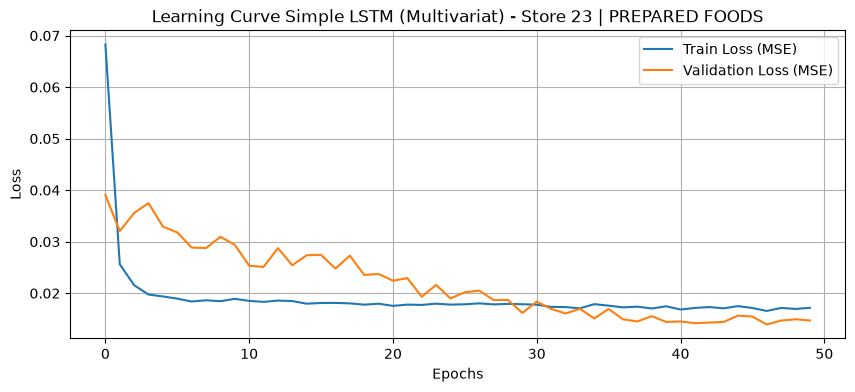

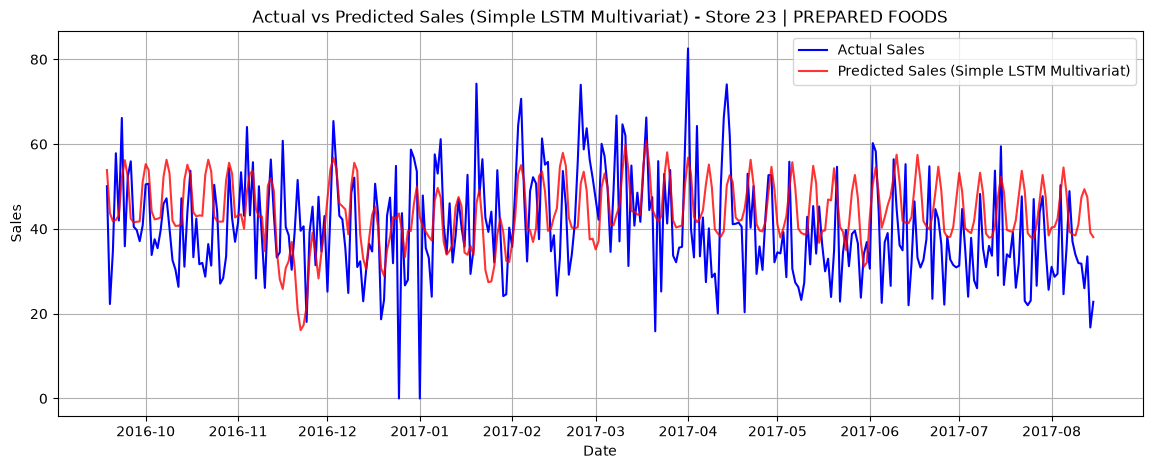

In [17]:
model_simple_comb5 = build_simple_lstm(look_back=30, num_features=data_comb5['num_features'])
rmsle_simple_comb5 = train_and_evaluate(
    model_simple_comb5, data_comb5, 
    model_name="Simple LSTM", store_nbr=23, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

### Kombinasi 5 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 23 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0416 - val_loss: 0.0318
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0253 - val_loss: 0.0179
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0235 - val_loss: 0.0180
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0217 - val_loss: 0.0149
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0207 - val_loss: 0.0137
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0210 - val_loss: 0.0133
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0196 - val_loss: 0.0140
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0204 - val_loss: 0.0145
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0199 - val_loss: 0.0127
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0192 - val_loss: 0.0127
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0206 - val_loss: 0.0126
Epoch

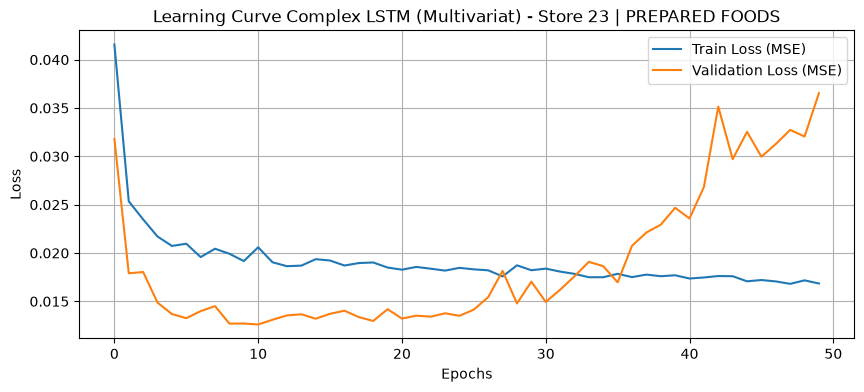

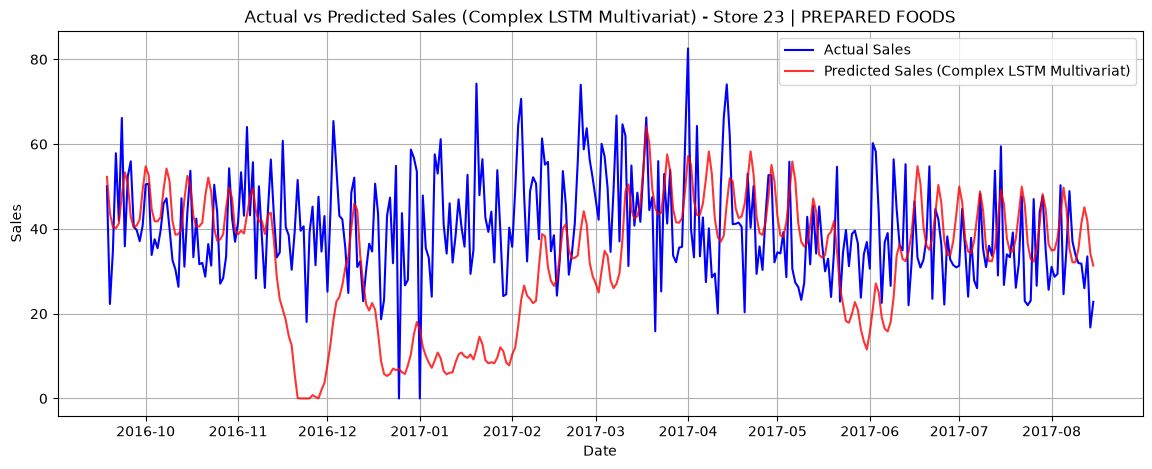

In [18]:
model_complex_comb5 = build_complex_lstm(look_back=30, num_features=data_comb5['num_features'])
rmsle_complex_comb5 = train_and_evaluate(
    model_complex_comb5, data_comb5, 
    model_name="Complex LSTM", store_nbr=23, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 6: Store 44 - GROCERY I

In [19]:
# Prepare Data Kombinasi 6 (Store 44, GROCERY I)
data_comb6 = prepare_data_multivariate_lstm(df_train, df_stores, oil_complete, valid_holidays, store_nbr=44, family='GROCERY I', look_back=30)
print(f"Data Kombinasi 6 (Store 44 - GROCERY I) Siap (Multivariat)!")
print(f"Shape X_train: {data_comb6['X_train'].shape}, Shape X_test: {data_comb6['X_test'].shape}")
print(f"Jumlah Fitur: {data_comb6['num_features']} -> {data_comb6['feature_cols']}")

Data Kombinasi 6 (Store 44 - GROCERY I) Siap (Multivariat)!
Shape X_train: (1326, 30, 10), Shape X_test: (332, 30, 10)
Jumlah Fitur: 10 -> ['sales', 'onpromotion', 'promo_rolling_mean_7', 'oil_price', 'is_holiday', 'is_weekend', 'is_payday', 'day_sin', 'day_cos', 'sales_lag_7']


### Kombinasi 6 - Model LSTM Sederhana

=== Training Simple LSTM (Store 44 - GROCERY I) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0077 - val_loss: 0.0043
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039 - val_loss: 0.0046
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 12/50

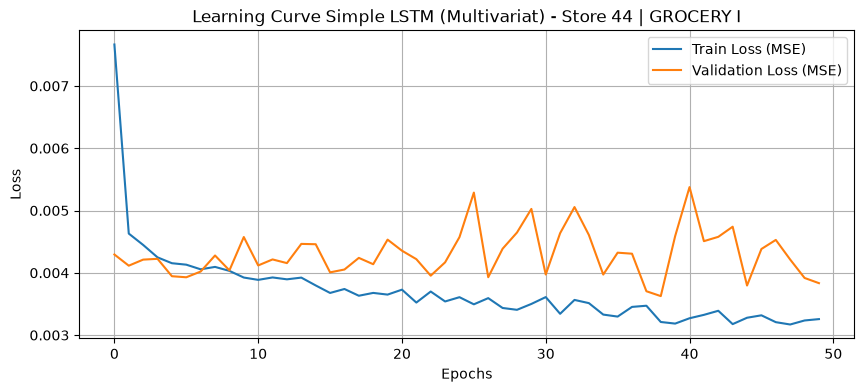

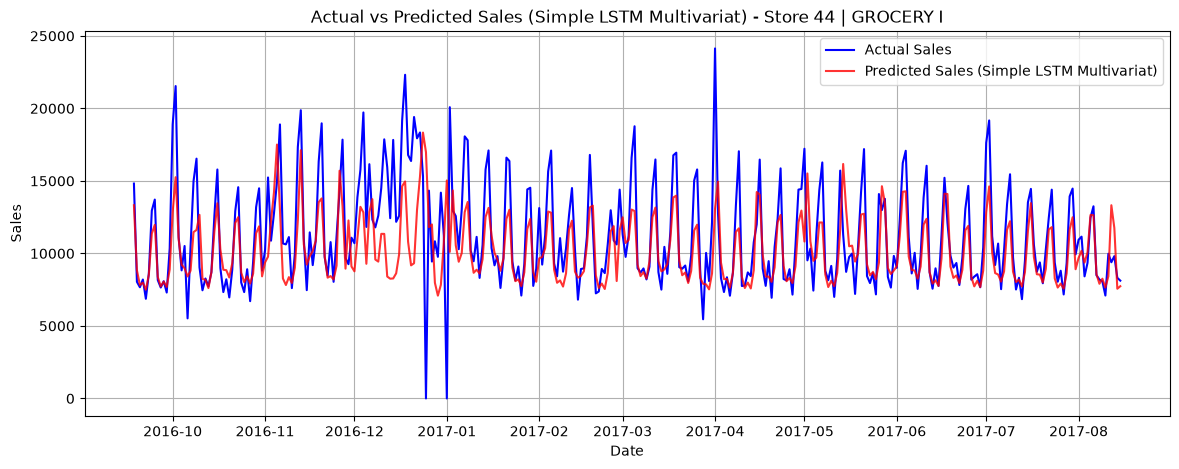

In [20]:
model_simple_comb6 = build_simple_lstm(look_back=30, num_features=data_comb6['num_features'])
rmsle_simple_comb6 = train_and_evaluate(
    model_simple_comb6, data_comb6, 
    model_name="Simple LSTM", store_nbr=44, family="GROCERY I", 
    epochs=50, batch_size=32
)

### Kombinasi 6 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 44 - GROCERY I) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0106 - val_loss: 0.0056
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0059 - val_loss: 0.0051
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0055 - val_loss: 0.0047
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0052 - val_loss: 0.0043
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0045 - val_loss: 0.0039
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0042 - val_loss: 0.0037
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0045 - val_loss: 0.0036
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 12/5

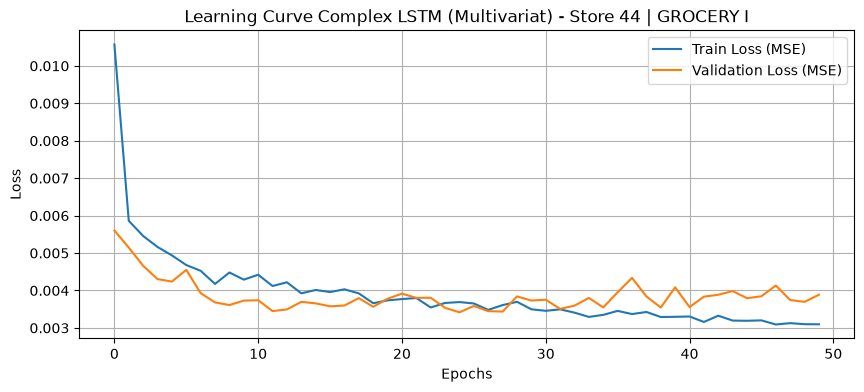

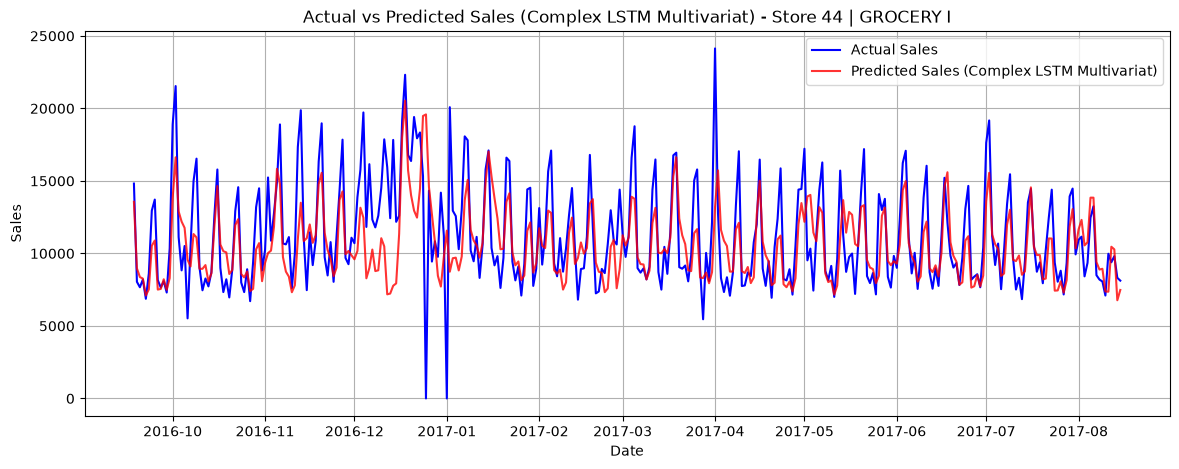

In [21]:
model_complex_comb6 = build_complex_lstm(look_back=30, num_features=data_comb6['num_features'])
rmsle_complex_comb6 = train_and_evaluate(
    model_complex_comb6, data_comb6, 
    model_name="Complex LSTM", store_nbr=44, family="GROCERY I", 
    epochs=50, batch_size=32
)

---
## Ringkasan Perbandingan Performa Eksperimen

In [22]:
summary_data = [
    {'Store': 23, 'Family': 'EGGS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb1},
    {'Store': 23, 'Family': 'EGGS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb1},
    {'Store': 54, 'Family': 'MEATS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb2},
    {'Store': 54, 'Family': 'MEATS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb2},
    {'Store': 19, 'Family': 'PREPARED FOODS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb3},
    {'Store': 19, 'Family': 'PREPARED FOODS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb3},
    {'Store': 7, 'Family': 'SEAFOOD', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb4},
    {'Store': 7, 'Family': 'SEAFOOD', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb4},
    {'Store': 23, 'Family': 'PREPARED FOODS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb5},
    {'Store': 23, 'Family': 'PREPARED FOODS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb5},
    {'Store': 44, 'Family': 'GROCERY I', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb6},
    {'Store': 44, 'Family': 'GROCERY I', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb6}
]

df_summary = pd.DataFrame(summary_data)
display(df_summary)

Store,Family,Model,RMSLE
23,EGGS,Simple LSTM,0.367888
23,EGGS,Complex LSTM,0.367854
54,MEATS,Simple LSTM,0.398397
54,MEATS,Complex LSTM,0.400432
19,PREPARED FOODS,Simple LSTM,0.398521
19,PREPARED FOODS,Complex LSTM,0.403964
7,SEAFOOD,Simple LSTM,0.452335
7,SEAFOOD,Complex LSTM,0.428080
23,PREPARED FOODS,Simple LSTM,0.429285
23,PREPARED FOODS,Complex LSTM,0.898802


### Perbandingan Komparatif: Univariat (Lookback 14 & 30) vs Multivariat (Lookback 30 - Set A)

Store,Family,Model,RMSLE (Univariat LB 14),RMSLE (Univariat LB 30),RMSLE (Multivariat LB 30),Delta vs Univariat 30
23,EGGS,Simple LSTM,0.369090,0.365793,0.367888,0.002095
23,EGGS,Complex LSTM,0.379503,0.369177,0.367854,-0.001323
54,MEATS,Simple LSTM,0.413072,0.397368,0.398397,0.001029
54,MEATS,Complex LSTM,0.387334,0.386911,0.400432,0.013521
19,PREPARED FOODS,Simple LSTM,0.421896,0.433796,0.398521,-0.035275
19,PREPARED FOODS,Complex LSTM,0.418090,0.417965,0.403964,-0.014001
7,SEAFOOD,Simple LSTM,0.422298,0.428314,0.452335,0.024021
7,SEAFOOD,Complex LSTM,0.430998,0.456076,0.428080,-0.027996
23,PREPARED FOODS,Simple LSTM,0.439800,0.446348,0.429285,-0.017063
23,PREPARED FOODS,Complex LSTM,0.445774,0.447396,0.898802,0.451406


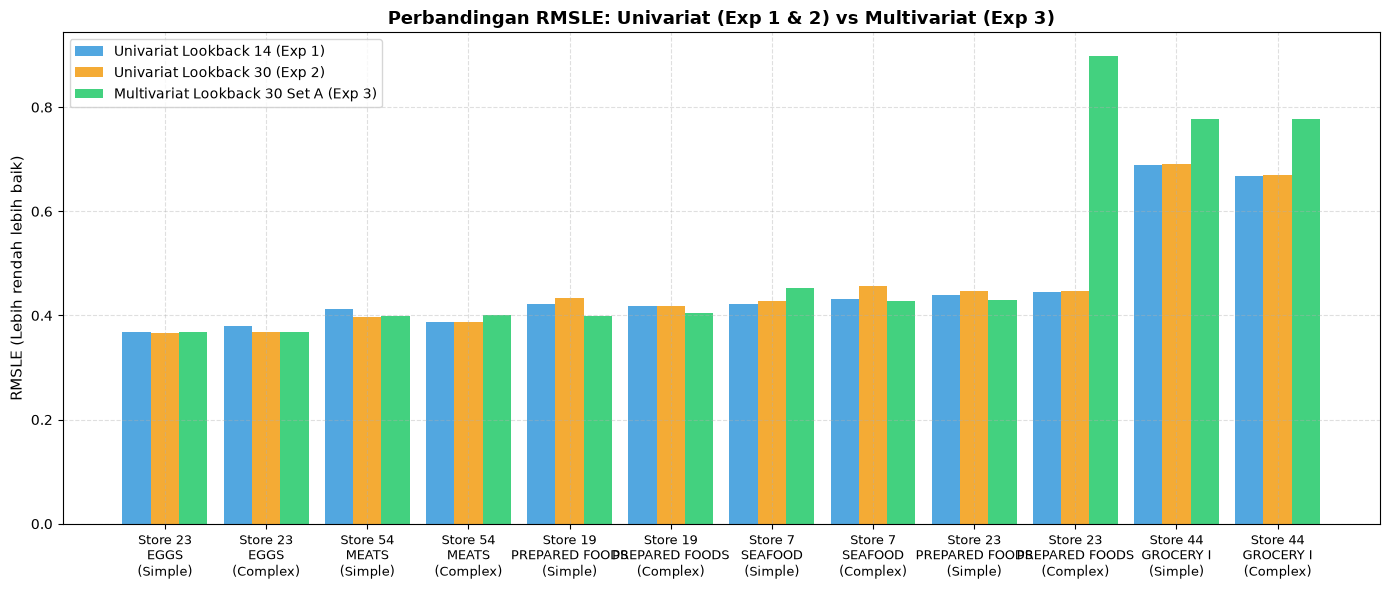

In [23]:
# Perbandingan Komparatif Eksperimen 1, 2, dan 3
exp1_rmsle = [0.369090, 0.379503, 0.413072, 0.387334, 0.421896, 0.418090, 0.422298, 0.430998, 0.439800, 0.445774, 0.689337, 0.667428]
exp2_rmsle = [0.365793, 0.369177, 0.397368, 0.386911, 0.433796, 0.417965, 0.428314, 0.456076, 0.446348, 0.447396, 0.691444, 0.669830]

df_comparison = df_summary.copy()
df_comparison['RMSLE (Univariat LB 14)'] = exp1_rmsle
df_comparison['RMSLE (Univariat LB 30)'] = exp2_rmsle
df_comparison.rename(columns={'RMSLE': 'RMSLE (Multivariat LB 30)'}, inplace=True)
df_comparison['Delta vs Univariat 30'] = df_comparison['RMSLE (Multivariat LB 30)'] - df_comparison['RMSLE (Univariat LB 30)']

display(df_comparison)

# Visualisasi Bar Chart Perbandingan
plt.figure(figsize=(14, 6))
x = np.arange(len(df_comparison))
width = 0.28

plt.bar(x - width, df_comparison['RMSLE (Univariat LB 14)'], width, label='Univariat Lookback 14 (Exp 1)', color='#3498db', alpha=0.85)
plt.bar(x, df_comparison['RMSLE (Univariat LB 30)'], width, label='Univariat Lookback 30 (Exp 2)', color='#f39c12', alpha=0.85)
plt.bar(x + width, df_comparison['RMSLE (Multivariat LB 30)'], width, label='Multivariat Lookback 30 Set A (Exp 3)', color='#2ecc71', alpha=0.9)

labels = [f"Store {r['Store']}\n{r['Family']}\n({r['Model'].split()[0]})" for _, r in df_comparison.iterrows()]
plt.xticks(x, labels, fontsize=9)
plt.ylabel('RMSLE (Lebih rendah lebih baik)', fontsize=11)
plt.title('Perbandingan RMSLE: Univariat (Exp 1 & 2) vs Multivariat (Exp 3)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()